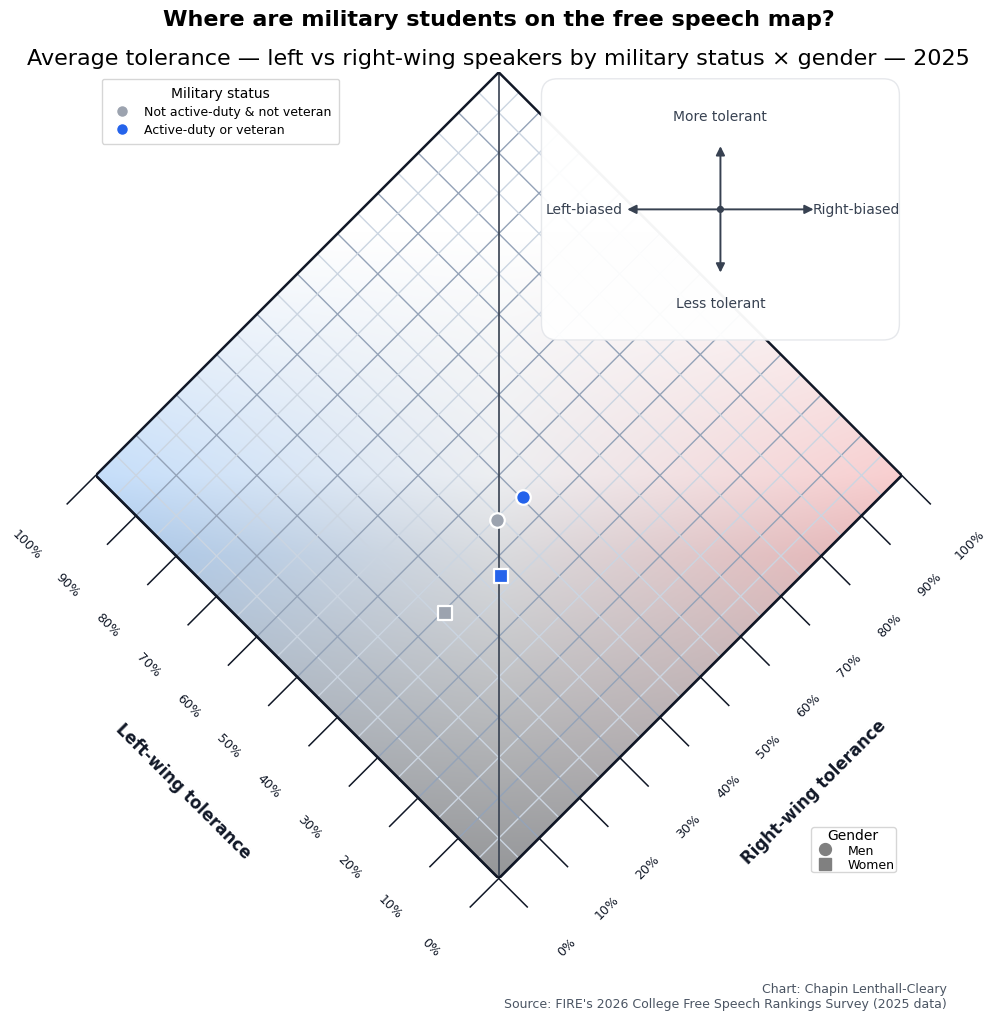

Figure saved to: /Users/chapin.lenthall-cleary/scatter_left_vs_right_avg_by_military_gender.png

Counts by Military Status × Gender:
                Men  Women  Total
military_bin                     
0             23655  40152  63807
1               676    526   1202
All           24331  40678  65009


Dropdown(description='Military:', options=(('0: Not active-duty & not veteran', 0), ('1: Active-duty or vetera…

Output()

In [12]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Circle, Polygon
from pathlib import Path

# Optional widget support (Jupyter)
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAVE_WIDGETS = True
except Exception:
    HAVE_WIDGETS = False

# --- Config ---
CSV_PATH = Path("cfsrALL_24_25.csv")
YEAR = 2025

# --- Compass sizing/position ---
BASE_COMPASS_W     = 0.30
BASE_COMPASS_H     = 0.30
BASE_COMPASS_SHIFT = 0.055
H_EXPAND_PP        = 0.12
COMPASS_W     = BASE_COMPASS_W + H_EXPAND_PP
COMPASS_H     = BASE_COMPASS_H
COMPASS_SHIFT = BASE_COMPASS_SHIFT - (COMPASS_W - BASE_COMPASS_W) / 2.0

IDEO_LABELS = {
    1: "Very liberal", 2: "Somewhat liberal", 3: "Slightly liberal",
    4: "Moderate, middle-of-the-road", 5: "Slightly conservative",
    6: "Somewhat conservative", 7: "Very conservative",
    8: "Democratic Socialist", 9: "Libertarian",
    10: "Haven't thought much about this", 11: "Something else",
}

# --- Military bin: anyone currently in armed forces OR a veteran ---
# Codebooks:
# veteran:     0 No, 1 Yes, 98 Not in survey, 99 Missing
# armedforces: 0 No, 1 Yes, 98 Not in survey, 99 Missing
#
# Binning rule:
#   YES (1) if either armedforces==1 OR veteran==1
#   NO  (0) only if both armedforces==0 AND veteran==0
#   otherwise -> missing (excluded)
MILITARY_LABELS = {
    0: "Not active-duty & not veteran",
    1: "Active-duty or veteran",
}
MILITARY_ORDER = [0, 1]

# Triads
RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]
LEFT_TRIAD  = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD

def scale_triad_to_pct(sum_vals, k=3):
    return (sum_vals - k) / (3 * k) * 100.0

def build_ideo_like_code(df: pd.DataFrame) -> pd.Series:
    to_num = lambda c: pd.to_numeric(df.get(c), errors="coerce")
    fire, cp, raw = to_num("fire_ideo"), to_num("cp_ideo"), to_num("ideo")
    valid_fire = (fire >= 1) & (fire <= 11)
    valid_cp   = (cp   >= 1) & (cp   <= 11)
    valid_raw  = (raw  >= 1) & (raw  <= 11)
    ideo = np.where(valid_fire, fire, np.where(valid_cp, cp, np.where(valid_raw, raw, np.nan)))
    return pd.Series(ideo, index=df.index).astype("Int64")

def build_military_bin(df: pd.DataFrame) -> pd.Series:
    af  = pd.to_numeric(df.get("armedforces"), errors="coerce")
    vet = pd.to_numeric(df.get("veteran"), errors="coerce")

    yes = (af == 1) | (vet == 1)
    no  = (af == 0) & (vet == 0)

    out = np.where(yes, 1, np.where(no, 0, np.nan))
    return pd.Series(out, index=df.index).astype("Int64")

def _mil_adj(m_int: int) -> str:
    """For dynamic Plot 2 suptitle wording (sentence case)."""
    return "military" if int(m_int) == 1 else "nonmilitary"

# ---------- Diamond mapping ----------
P0 = np.array([50.0, 0.0])
VL = np.array([-50.0, 50.0])
VR = np.array([ 50.0, 50.0])
def to_diamond(L, R):
    sL, sR = np.asarray(L)/100.0, np.asarray(R)/100.0
    xy = P0 + sL*VL + sR*VR
    return float(xy[0]), float(xy[1])

# ---------- 2-D gradient background (clipped) ----------
def _add_2d_gradient_bg(ax, diamond_outline, *, nx=800, ny=800):
    x = np.linspace(0.0, 1.0, nx)
    y = np.linspace(0.0, 1.0, ny)
    X, Y = np.meshgrid(x, y)

    c_left  = np.array(to_rgb("#93c5fd"))
    c_mid   = np.array(to_rgb("#e5e7eb"))
    c_right = np.array(to_rgb("#fca5a5"))

    H = np.zeros((ny, nx, 3), dtype=float)
    uL = np.clip(2*X, 0, 1)
    uR = np.clip(2*(X - 0.5), 0, 1)
    for ch in range(3):
        H[..., ch] = np.where(
            X <= 0.5,
            (1 - uL) * c_left[ch] + uL * c_mid[ch],
            (1 - uR) * c_mid[ch]  + uR * c_right[ch]
        )

    white = np.array(to_rgb("#ffffff"))
    gray  = np.array(to_rgb("#e5e7eb"))
    t = np.clip(Y / 0.80, 0, 1)
    V = (1 - t)[..., None] * gray + t[..., None] * white

    bell = 1.0 - np.abs(2*t - 1.0)
    alpha = 0.65 * bell
    IMG = (1 - alpha)[..., None] * V + alpha[..., None] * H

    bottom_cutoff = 0.5
    shade_strength = np.clip((bottom_cutoff - Y) / bottom_cutoff, 0.0, 1.0)
    max_darken = 0.35
    darken_factor = 1.0 - max_darken * shade_strength[..., None]
    IMG *= darken_factor
    IMG = np.clip(IMG, 0.0, 1.0)
    IMG[Y >= 0.85] = white

    im = ax.imshow(IMG, origin="lower", extent=[0, 100, 0, 100],
                   interpolation="bilinear", zorder=-10)
    im.set_clip_path(diamond_outline)

# ---------- Compass ----------
def add_compass(ax, *, width, height, pad=0.02, shift_left,
                directions_deg, labels):
    cx = 1 - pad - width / 2 - shift_left
    cy = 1 - pad - height / 2

    FancyFbox = FancyBboxPatch(
        (cx - width/2, cy - height/2), width, height,
        transform=ax.transAxes, boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=1.0, facecolor="white", edgecolor="#e5e7eb", alpha=0.96, zorder=8
    )
    ax.add_patch(FancyFbox)

    hx, hy = width / 2.0, height / 2.0
    m = min(width, height) * 0.06
    def r_max(theta):
        ct, st = abs(np.cos(theta)), abs(np.sin(theta))
        ct = max(ct, 1e-9); st = max(st, 1e-9)
        return min((hx - m) / ct, (hy - m) / st)

    color = "#374151"; lw = 1.4; ms = 13; fz = 10.0
    for angle_deg, label in zip(directions_deg, labels):
        th = np.deg2rad(angle_deg)
        rmax = r_max(th); r_arrow = rmax * 0.62; r_label = rmax * 0.88
        x_tip = cx + r_arrow * np.cos(th); y_tip = cy + r_arrow * np.sin(th)
        ax.add_patch(FancyArrowPatch(
            (cx, cy), (x_tip, y_tip),
            transform=ax.transAxes, arrowstyle="-|>", mutation_scale=ms,
            linewidth=lw, color=color, zorder=9
        ))
        ax.text(cx + r_label*np.cos(th), cy + r_label*np.sin(th),
                label, transform=ax.transAxes, ha="center", va="center",
                fontsize=fz, color=color, zorder=10)
    ax.add_patch(Circle((cx, cy), radius=min(width, height) * 0.012,
                        transform=ax.transAxes, color=color, zorder=10))

# ---------- Oblique edge axes ----------
def _draw_edge_axis(ax, p0, p1, *, label, tick_vals=range(0, 101, 10),
                    tick_len=4.0, label_pad=18.0, tick_label_pad=6.0,
                    label_fontsize=12, tick_fontsize=9, color="#111827",
                    increasing_from="start"):
    p0 = np.asarray(p0, float); p1 = np.asarray(p1, float)
    v = p1 - p0; L = float(np.hypot(v[0], v[1]))
    if L == 0: return
    u = v / L
    n_cw  = np.array([ u[1], -u[0]])
    n_ccw = np.array([-u[1],  u[0]])
    n = n_cw if n_cw[1] < n_ccw[1] else n_ccw

    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, linewidth=1.6, zorder=4)
    edge_angle_deg = np.degrees(np.arctan2(v[1], v[0]))

    for t in tick_vals:
        s = t / 100.0
        pt = (p1 - u*(s*L)) if (increasing_from == "end") else (p0 + u*(s*L))
        p_tick_end = pt + n * tick_len
        ax.plot([pt[0], p_tick_end[0]], [pt[1], p_tick_end[1]],
                color=color, linewidth=1.1, zorder=4, clip_on=False)
        p_text = pt + n * (tick_len + tick_label_pad)
        ax.text(p_text[0], p_text[1], f"{t}%", ha="center", va="center",
                fontsize=tick_fontsize, color=color,
                rotation=edge_angle_deg, rotation_mode="anchor",
                zorder=5, clip_on=False)

    mid = (p0 + p1) / 2.0
    p_label = mid + n * label_pad
    ax.text(p_label[0], p_label[1], label, ha="center", va="center",
            fontsize=label_fontsize, color=color, fontweight="bold",
            rotation=edge_angle_deg, rotation_mode="anchor",
            zorder=5, clip_on=False)

# ---------- Shared style ----------
cmap_lr = LinearSegmentedColormap.from_list("blue_purple_red",
                                            ["#084594", "#6a51a3", "#b10026"])
steps7 = np.linspace(0, 1, 7)
IDEOLOGY_COLORS = {i: cmap_lr(steps7[i - 1]) for i in range(1, 8)}
IDEOLOGY_COLORS.update({8: "#31a354", 9: "#ffd92f", 10: "#d1d5db", 11: "#9ca3af"})
GENDER_MARKERS = {1: "o", 2: "s"}

# ---------- Helpers ----------
def _prep_stats(df: pd.DataFrame, group_cols):
    d = df.copy()
    d["right_sum"] = d[RIGHT_TRIAD].sum(axis=1).astype(int)
    d["left_sum"]  = d[LEFT_TRIAD].sum(axis=1).astype(int)
    d["right_pct"] = scale_triad_to_pct(d["right_sum"], k=len(RIGHT_TRIAD))
    d["left_pct"]  = scale_triad_to_pct(d["left_sum"],  k=len(LEFT_TRIAD))
    stats = (d.groupby(group_cols, dropna=True)
               .agg(left_avg=("left_pct", "mean"),
                    right_avg=("right_pct", "mean"),
                    n=("left_pct", "size"))
               .reset_index())
    return stats

def _draw_diamond(ax):
    diamond_xy = np.array([[50, 100], [100, 50], [50, 0], [0, 50]], dtype=float)
    diamond_outline = Polygon(diamond_xy, closed=True, facecolor="none",
                              edgecolor="#111827", linewidth=1.8, zorder=3, joinstyle="miter")
    ax.add_patch(diamond_outline)
    _add_2d_gradient_bg(ax, diamond_outline)

    # grid
    grid_artists = []
    light_line = "#cbd5e1"; heavy_line = "#94a3b8"
    for v in range(0, 101, 5):
        color = heavy_line if (v // 5) % 2 == 0 else light_line
        x1, y1 = to_diamond(v, 0); x2, y2 = to_diamond(v, 100)
        ln1, = ax.plot([x1, x2], [y1, y2], color=color, linewidth=1.0, zorder=0)
        x3, y3 = to_diamond(0, v); x4, y4 = to_diamond(100, v)
        ln2, = ax.plot([x3, x4], [y3, y4], color=color, linewidth=1.0, zorder=0)
        grid_artists += [ln1, ln2]
    x0, y0 = to_diamond(0, 0); xT, yT = to_diamond(100, 100)
    parity_line, = ax.plot([x0, xT], [y0, yT], color="#374151", linewidth=1.2, zorder=1.5)
    for art in grid_artists + [parity_line]:
        art.set_clip_path(ax.patches[0])

    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect("equal", adjustable="box")

    _draw_edge_axis(ax, (0, 50), (50, 0), label="Left-wing tolerance",
                    increasing_from="end", label_pad=20, tick_label_pad=7, tick_len=5.0,
                    label_fontsize=12, tick_fontsize=9)
    _draw_edge_axis(ax, (50, 0), (100, 50), label="Right-wing tolerance",
                    label_pad=20, tick_label_pad=7, tick_len=5.0,
                    label_fontsize=12, tick_fontsize=9)

    compass_dirs  = [90, 180, 0, 270]
    compass_labels= ["More tolerant", "Left-biased", "Right-biased", "Less tolerant"]
    add_compass(ax, width=COMPASS_W, height=COMPASS_H, pad=0.02, shift_left=COMPASS_SHIFT,
                directions_deg=compass_dirs, labels=compass_labels)

def _counts_military_gender(df):
    ct = (df.groupby(["military_bin", "gender_bin"])
            .size()
            .unstack(fill_value=0)
            .reindex(index=MILITARY_ORDER, columns=[1, 2], fill_value=0))
    ct.columns = ["Men", "Women"]
    ct["Total"] = ct.sum(axis=1)
    ct.loc["All"] = ct.sum(axis=0)
    return ct

# ---------- Plot 1: Military/Veteran × Gender (static), with PRINTED table ----------
def make_military_gender_scatter(df: pd.DataFrame, year: int):
    stats = _prep_stats(df, ["military_bin", "gender_bin"])
    if stats.empty:
        raise SystemExit("No groups to plot for Military/Veteran × gender.")

    fig, ax = plt.subplots(figsize=(11.2, 11.0))
    _draw_diamond(ax)

    MIL_COLORS = {
        0: "#9ca3af",  # neither
        1: "#2563eb",  # active-duty or veteran
    }

    for _, row in stats.iterrows():
        m, g = int(row["military_bin"]), int(row["gender_bin"])
        x_t, y_t = to_diamond(row["left_avg"], row["right_avg"])
        ax.scatter(
            x_t, y_t, s=110, c=[MIL_COLORS.get(m, "#9ca3af")],
            marker=GENDER_MARKERS.get(g, "o"),
            edgecolor="white", linewidth=1.6, zorder=4
        )

    mil_handles = [
        Line2D([0],[0], marker="o", linestyle="",
               markerfacecolor=MIL_COLORS[i], markeredgecolor="white",
               markersize=9, label=MILITARY_LABELS[i])
        for i in MILITARY_ORDER
    ]
    gender_handles = [
        Line2D([0],[0], marker=GENDER_MARKERS[1], linestyle="", color="gray", label="Men", markersize=9),
        Line2D([0],[0], marker=GENDER_MARKERS[2], linestyle="", color="gray", label="Women", markersize=9),
    ]

    leg1 = ax.legend(handles=mil_handles, title="Military status", loc="upper left",
                     frameon=True, fontsize=9, title_fontsize=10, markerscale=0.95,
                     borderpad=0.6, labelspacing=0.4)
    ax.add_artist(leg1)
    ax.legend(handles=gender_handles, title="Gender", loc="lower right",
              frameon=True, fontsize=9, title_fontsize=10, markerscale=0.95,
              borderpad=.1, labelspacing=0.1)

    # Sentence case titles
    ax.set_title(
        f"Average tolerance — left vs right-wing speakers by military status × gender — {year}",
        fontsize=16
    )
    fig.suptitle(
        "Where are military students on the free speech map?",
        fontsize=16, fontweight="bold", y=0.94
    )

    fig.text(0.9, 0.03,
             "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
             ha="right", va="bottom", fontsize=9, color="#4b5563")

    fig.tight_layout(rect=[0.02, 0.06, 0.98, 0.95])
    out_path = Path("scatter_left_vs_right_avg_by_military_gender.png")
    fig.savefig(out_path, dpi=220)
    plt.show()
    print(f"Figure saved to: {out_path.resolve()}")

    # ---- PRINTED counts table (not embedded) ----
    ct = _counts_military_gender(df)
    print("\nCounts by Military Status × Gender:")
    print(ct.to_string())

# ---------- Plot 2: Ideology × Gender — WIDGET to swap Military bin, with PRINTED table ----------
def show_ideo_gender_by_military_widget(df: pd.DataFrame, year: int):
    """
    Jupyter-only interactive: choose military bin (0/1) and redraw diamond plot of ideology × gender.
    Also PRINT a table of counts (ideology × gender) beneath the figure.
    """
    if not HAVE_WIDGETS:
        raise RuntimeError("ipywidgets not available. Install with: pip install ipywidgets")

    stats_all = _prep_stats(df, ["ideo", "gender_bin", "military_bin"])
    stats_all = stats_all[stats_all["military_bin"].isin(MILITARY_ORDER)]
    if stats_all.empty:
        raise SystemExit("No groups to plot for Ideology × Gender by Military status.")

    # Precompute counts for table
    counts = (df.groupby(["military_bin", "ideo", "gender_bin"]).size().reset_index(name="n"))

    options = [(f"{m}: {MILITARY_LABELS[m]}", m) for m in MILITARY_ORDER]
    dd = widgets.Dropdown(options=options, value=0, description="Military:")
    out = widgets.Output()

    def render(m_int: int):
        with out:
            out.clear_output(wait=True)

            fig, ax = plt.subplots(figsize=(11.2, 11.0))
            _draw_diamond(ax)

            sub = stats_all[stats_all["military_bin"] == m_int]
            for _, row in sub.iterrows():
                i, g = int(row["ideo"]), int(row["gender_bin"])
                x_t, y_t = to_diamond(row["left_avg"], row["right_avg"])
                ax.scatter(x_t, y_t, s=95,
                           c=[IDEOLOGY_COLORS.get(i, "#9ca3af")],
                           marker=GENDER_MARKERS.get(g, "o"),
                           edgecolor="white", linewidth=1.4, zorder=4)

            ideo_handles = [Line2D([0],[0], marker="o", linestyle="",
                                   markerfacecolor=IDEOLOGY_COLORS[i], markeredgecolor="white", markersize=8,
                                   label=IDEO_LABELS[i]) for i in range(1, 12)]
            gender_handles = [
                Line2D([0],[0], marker=GENDER_MARKERS[1], linestyle="", color="gray", label="Men", markersize=8),
                Line2D([0],[0], marker=GENDER_MARKERS[2], linestyle="", color="gray", label="Women", markersize=8),
            ]
            leg1 = ax.legend(handles=ideo_handles, title="Ideology", loc="upper left",
                             frameon=True, fontsize=8, title_fontsize=9, borderpad=0.6, labelspacing=0.3)
            ax.add_artist(leg1)
            ax.legend(handles=gender_handles, title="Gender", loc="lower right",
                      frameon=True, fontsize=8, title_fontsize=9, borderpad=0.3)

            # Sentence case titles
            ax.set_title(f"Ideology × gender — {MILITARY_LABELS[m_int]} — {year}", fontsize=15)

            adj = _mil_adj(m_int)
            fig.suptitle(
                f"Where are {adj} men and women on the free speech map?",
                fontsize=15, fontweight="bold", y=0.97
            )

            fig.text(0.9, 0.03,
                     "Chart: Chapin Lenthall-Cleary • Source: FIRE's 2026 CFSR (2025 data)",
                     ha="right", va="bottom", fontsize=9, color="#4b5563")

            fig.tight_layout(rect=[0.02, 0.06, 0.98, 0.94])
            plt.show()

            # --- PRINTED table for this military bin: ideology × gender (+ totals) ---
            subc = counts[counts["military_bin"] == m_int]
            piv = (subc.pivot_table(index="ideo", columns="gender_bin", values="n",
                                    aggfunc="sum", fill_value=0)
                         .reindex(index=range(1, 12), fill_value=0)
                         .reindex(columns=[1, 2], fill_value=0))
            piv.columns = ["Men", "Women"]
            piv["Total"] = piv.sum(axis=1)
            piv.loc["All"] = piv.sum(axis=0)

            print(f"\nCounts by Ideology × Gender ({MILITARY_LABELS[m_int]}):")
            row_labels = [IDEO_LABELS[i] for i in range(1, 12)] + ["All"]
            piv_str = pd.DataFrame(piv.values, index=row_labels, columns=piv.columns).to_string()
            print(piv_str)

    def _on_change(ch):
        if ch["name"] == "value" and ch["new"] in MILITARY_ORDER:
            render(int(ch["new"]))

    dd.observe(_on_change, names="value")
    display(dd, out)
    render(dd.value)

# ---------- (Optional) legacy single-panel plot ----------
def make_ideo_gender_scatter(df: pd.DataFrame, year: int):
    stats = _prep_stats(df, ["ideo", "gender_bin"])
    if stats.empty:
        raise SystemExit("No groups to plot after filtering—check data/filtering.")
    fig, ax = plt.subplots(figsize=(11.2, 11.0))
    _draw_diamond(ax)
    for _, row in stats.iterrows():
        i, g = int(row["ideo"]), int(row["gender_bin"])
        x_t, y_t = to_diamond(row["left_avg"], row["right_avg"])
        ax.scatter(x_t, y_t, s=110,
                   c=[IDEOLOGY_COLORS.get(i, "#9ca3af")],
                   marker=GENDER_MARKERS.get(g, "o"),
                   edgecolor="white", linewidth=1.6, zorder=4)
    ideo_handles = [Line2D([0],[0], marker="o", linestyle="",
                           markerfacecolor=IDEOLOGY_COLORS[i], markeredgecolor="white", markersize=9,
                           label=IDEO_LABELS[i]) for i in range(1, 12)]
    gender_handles = [
        Line2D([0],[0], marker=GENDER_MARKERS[1], linestyle="", color="gray", label="Men", markersize=9),
        Line2D([0],[0], marker=GENDER_MARKERS[2], linestyle="", color="gray", label="Women", markersize=9),
    ]
    leg1 = ax.legend(handles=ideo_handles, title="Ideology", loc="upper left",
                     frameon=True, fontsize=9, title_fontsize=10, markerscale=0.95,
                     borderpad=0.6, labelspacing=0.4)
    ax.add_artist(leg1)
    ax.legend(handles=gender_handles, title="Gender", loc="lower right",
              frameon=True, fontsize=9, title_fontsize=10, markerscale=0.95,
              borderpad=.1, labelspacing=0.1)

    # Sentence case title
    ax.set_title(
        f"Average tolerance — left vs right-wing speakers by ideology × gender — {year}",
        fontsize=16
    )

    fig.tight_layout(rect=[0.02, 0.11, 0.98, 0.92])
    out_path = Path("scatter_left_vs_right_avg_by_ideology_gender.png")
    fig.savefig(out_path, dpi=220)
    plt.show()
    print(f"Figure saved to: {out_path.resolve()}")

# ---------- Main ----------
def main():
    df = pd.read_csv(CSV_PATH, low_memory=False)

    # numeric conversions (include armedforces/veteran)
    for col in ["datayear", "gender_bin", "armedforces", "veteran", *SPK_ALL]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["ideo"] = build_ideo_like_code(df)
    df["military_bin"] = build_military_bin(df)

    # Base filters: year, binary gender, valid ideology, military_bin 0/1, valid spk_* in [1,4]
    df = df[
        (df["datayear"] == YEAR) &
        (df["gender_bin"].isin([1, 2])) &
        (df["ideo"].isin(range(1, 12))) &
        (df["military_bin"].isin(MILITARY_ORDER))
    ]
    if df.empty:
        raise SystemExit(
            f"No rows for datayear == {YEAR}, genders in [1,2], ideo in 1..11, military_bin in {MILITARY_ORDER}."
        )

    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()
    if df.empty:
        raise SystemExit("No rows remain after requiring all six spk_* in [1,4].")

    # 1) Military/Veteran × Gender (static) + PRINTED table
    make_military_gender_scatter(df, YEAR)

    # 2) Ideology × Gender — WIDGET to swap Military bin, with PRINTED table
    if HAVE_WIDGETS:
        show_ideo_gender_by_military_widget(df, YEAR)
    else:
        # Fallback: export one PNG per military bin and print each table to stdout
        stats_all = _prep_stats(df, ["ideo", "gender_bin", "military_bin"])
        counts = (df.groupby(["military_bin", "ideo", "gender_bin"]).size().reset_index(name="n"))

        for m_int in MILITARY_ORDER:
            fig, ax = plt.subplots(figsize=(11.2, 11.0))
            _draw_diamond(ax)
            sub = stats_all[stats_all["military_bin"] == m_int]
            if sub.empty:
                plt.close(fig); continue

            for _, row in sub.iterrows():
                i, g = int(row["ideo"]), int(row["gender_bin"])
                x_t, y_t = to_diamond(row["left_avg"], row["right_avg"])
                ax.scatter(x_t, y_t, s=95,
                           c=[IDEOLOGY_COLORS.get(i, "#9ca3af")],
                           marker=GENDER_MARKERS.get(g, "o"),
                           edgecolor="white", linewidth=1.4, zorder=4)

            # Sentence case titles
            ax.set_title(f"Ideology × gender — {MILITARY_LABELS[m_int]} — {YEAR}", fontsize=15)

            adj = _mil_adj(m_int)
            fig.suptitle(
                f"Where are {adj} men and women on the free speech map?",
                fontsize=15, fontweight="bold", y=0.97
            )

            fig.tight_layout(rect=[0.02, 0.06, 0.98, 0.94])
            out_path = Path(f"scatter_left_vs_right_avg_ideo_gender_military_{m_int}.png")
            fig.savefig(out_path, dpi=220)
            plt.show()
            print(f"Figure saved to: {out_path.resolve()}")

            subc = counts[counts["military_bin"] == m_int]
            piv = (subc.pivot_table(index="ideo", columns="gender_bin", values="n",
                                    aggfunc="sum", fill_value=0)
                         .reindex(index=range(1, 12), fill_value=0)
                         .reindex(columns=[1, 2], fill_value=0))
            piv.columns = ["Men", "Women"]
            piv["Total"] = piv.sum(axis=1)
            piv.loc["All"] = piv.sum(axis=0)

            row_labels = [IDEO_LABELS[i] for i in range(1, 12)] + ["All"]
            print(f"\nCounts by Ideology × Gender ({MILITARY_LABELS[m_int]}):")
            print(pd.DataFrame(piv.values, index=row_labels, columns=piv.columns).to_string())

if __name__ == "__main__":
    main()


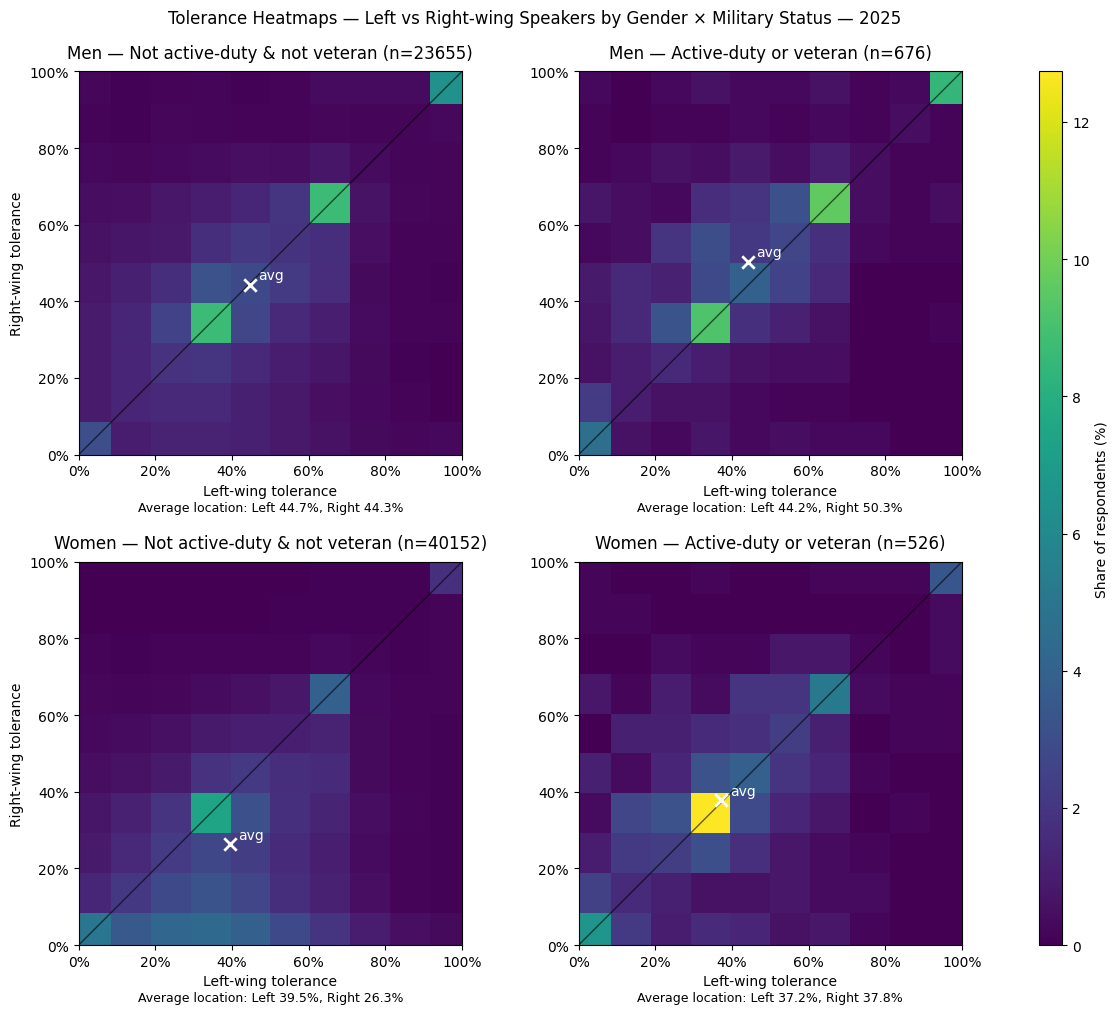

Figure saved to: /Users/chapin.lenthall-cleary/heatmap_left_vs_right_by_gender_military.png


In [10]:
#!/usr/bin/env python3
"""
Heatmaps of tolerance for Left- vs Right-wing speakers (x = Left, y = Right),
split into four groups:
  • Men — Not active-duty & not veteran
  • Men — Active-duty or veteran
  • Women — Not active-duty & not veteran
  • Women — Active-duty or veteran

Values are scaled to 0–100% using the same mapping as your triad plots
(sum k..4k -> 0..100 where k=len(triad)=3).

Outputs one figure with four panels and saves it to:
  heatmap_left_vs_right_by_gender_military.png
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

# --- Config ---
CSV_PATH = Path("cfsrALL_24_25.csv")
YEAR = 2025

GENDER_LABELS = {1: "Men", 2: "Women"}

# Military bin labels:
#   1 = either armedforces==1 OR veteran==1
#   0 = both armedforces==0 AND veteran==0
#   else -> missing (excluded)
MILITARY_LABELS = {
    0: "Not active-duty & not veteran",
    1: "Active-duty or veteran",
}

# Triads (keep your original naming)
RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]          # "Right-wing Speakers"
LEFT_TRIAD  = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]  # "Left-wing Speakers"
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD


def scale_triad_to_pct(sum_vals, k=3):
    """Maps triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def build_military_bin(df: pd.DataFrame) -> pd.Series:
    """
    Builds a nullable Int64 military_bin:
      YES (1) if either armedforces==1 OR veteran==1
      NO  (0) only if both armedforces==0 AND veteran==0
      otherwise NaN (e.g., 98/99/missing in either field)
    """
    af  = pd.to_numeric(df.get("armedforces"), errors="coerce")
    vet = pd.to_numeric(df.get("veteran"), errors="coerce")

    yes = (af == 1) | (vet == 1)
    no  = (af == 0) & (vet == 0)

    out = np.where(yes, 1, np.where(no, 0, np.nan))
    return pd.Series(out, index=df.index).astype("Int64")


def make_quad_heatmaps(df, year):
    """
    df: already filtered to year, gender=={1,2}, military_bin in {0,1}, all six spk_* in [1,4]
    Creates a 2x2 figure with a dedicated colorbar axis on the far right and
    a line of text below each plot describing the average location.
    """
    df = df.copy()

    # Triad sums & scale to percent (0..100)
    df["right_sum"] = df[RIGHT_TRIAD].sum(axis=1).astype(int)
    df["left_sum"]  = df[LEFT_TRIAD].sum(axis=1).astype(int)
    df["right_pct"] = scale_triad_to_pct(df["right_sum"], k=len(RIGHT_TRIAD))
    df["left_pct"]  = scale_triad_to_pct(df["left_sum"],  k=len(LEFT_TRIAD))

    # Binning edges: ~10% bins with small buffers so edge values show
    edges = np.linspace(-2, 102, 11)

    # --- Figure layout: 2x3 grid, last column reserved for colorbar ---
    fig = plt.figure(figsize=(13.2, 10.4))
    gs = fig.add_gridspec(
        nrows=2, ncols=3,
        width_ratios=[1, 1, 0.05],
        wspace=0.12, hspace=0.28
    )
    axes = [
        fig.add_subplot(gs[0, 0]),  # Men — Not active-duty & not veteran
        fig.add_subplot(gs[0, 1]),  # Men — Active-duty or veteran
        fig.add_subplot(gs[1, 0]),  # Women — Not active-duty & not veteran
        fig.add_subplot(gs[1, 1]),  # Women — Active-duty or veteran
    ]
    cax = fig.add_subplot(gs[:, 2])  # dedicated colorbar axis spanning both rows

    groups = [(1, 0), (1, 1), (2, 0), (2, 1)]  # (gender_bin, military_bin)

    # First pass: build grids and global vmax so colors are comparable
    cmax = 0.0
    grids = {}
    for (g, m) in groups:
        sub = df[(df["gender_bin"] == g) & (df["military_bin"] == m)]
        if sub.empty:
            grids[(g, m)] = (np.zeros((len(edges) - 1, len(edges) - 1)), edges, edges, 0, np.nan, np.nan)
            continue

        # NOTE: x = Left, y = Right
        H, xedges, yedges = np.histogram2d(sub["left_pct"], sub["right_pct"], bins=[edges, edges])
        pct = (H / len(sub)) * 100.0
        mx = sub["left_pct"].mean()
        my = sub["right_pct"].mean()
        grids[(g, m)] = (pct, xedges, yedges, len(sub), mx, my)
        cmax = max(cmax, pct.max())

    meshes = []
    for ax, (g, m) in zip(axes, groups):
        pct, xedges, yedges, n, mx, my = grids[(g, m)]
        mesh = ax.pcolormesh(
            xedges, yedges, pct.T,
            shading="auto", vmin=0, vmax=max(1e-9, cmax)
        )
        meshes.append(mesh)

        # Titles & labels
        title_txt = f"{GENDER_LABELS[g]} — {MILITARY_LABELS[m]} (n={n})"
        ax.set_title(title_txt, pad=10)

        ax.set_xlabel("Left-wing tolerance")
        if m == 0:  # left column → show y-label
            ax.set_ylabel("Right-wing tolerance")

        # 0..100% axes with percent tick formatting
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
        ax.set_aspect("equal", adjustable="box")

        # Diagonal parity line (Left == Right)
        ax.plot([0, 100], [0, 100], color="black", linewidth=1, alpha=0.6)

        # Group mean marker + label and text below plot
        if n > 0 and not (np.isnan(mx) or np.isnan(my)):
            ax.scatter([mx], [my], marker="x", s=80, color="white", linewidths=2, zorder=3)
            ax.annotate("avg", (mx, my), textcoords="offset points", xytext=(6, 4), color="white")
            avg_text = f"Average location: Left {mx:.1f}%, Right {my:.1f}%"
        else:
            avg_text = "Average location: —"

        ax.text(
            0.5, -0.12, avg_text,
            transform=ax.transAxes, ha="center", va="top",
            fontsize=9
        )

    # Dedicated colorbar (won't overlap plots)
    cbar = fig.colorbar(meshes[0], cax=cax)
    cbar.set_label("Share of respondents (%)")

    fig.suptitle(f"Tolerance Heatmaps — Left vs Right-wing Speakers by Gender × Military Status — {year}")
    fig.subplots_adjust(top=0.92, bottom=0.08)

    out_path = Path("heatmap_left_vs_right_by_gender_military.png")
    fig.savefig(out_path, dpi=150)
    plt.show()
    print(f"Figure saved to: {out_path.resolve()}")


def main():
    # Load
    df = pd.read_csv(CSV_PATH, low_memory=False)

    # Coerce relevant columns to numeric (include armedforces/veteran)
    numeric_cols = ["datayear", "gender_bin", "armedforces", "veteran", *SPK_ALL]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Build military bin
    df["military_bin"] = build_military_bin(df)

    # Filter to target year, men/women only, and military_bin {0,1}
    df = df[
        (df["datayear"] == YEAR) &
        (df["gender_bin"].isin([1, 2])) &
        (df["military_bin"].isin([0, 1]))
    ]
    if df.empty:
        raise SystemExit(f"No rows found for datayear == {YEAR}, genders in [1,2], and military_bin in [0,1].")

    # Require ALL six spk_* in [1,4], matching earlier scripts
    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()
    if df.empty:
        raise SystemExit("No rows remain after requiring all six spk_* to be in [1,4].")

    # Make the 2x2 heatmaps
    make_quad_heatmaps(df, YEAR)


if __name__ == "__main__":
    main()


In [11]:
#!/usr/bin/env python3
"""
Compute average unsigned distance from the *vertical centerline* (equal tolerance)
for Military vs Nonmilitary, split by Men/Women.

Outputs TWO sets of values:
  1) Not controlled for ideology (raw mean within group)
  2) Controlled for ideology via direct standardization:
        - compute mean distance within each (military, gender, ideology)
        - weight those ideology means by the OVERALL ideology distribution
        - renormalize weights within each group if some ideologies are missing

Distance is reported in DIAMOND X-units (0..50). If you prefer the absolute
left-right tolerance gap in percentage points, multiply distance by 2.
"""

import numpy as np
import pandas as pd
from pathlib import Path

# ---------------- Config ----------------
CSV_PATH = Path("cfsrALL_24_25.csv")
YEAR = 2025

# Triads (same as your plotting script)
RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]
LEFT_TRIAD  = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD

IDEO_LABELS = {
    1: "Very liberal", 2: "Somewhat liberal", 3: "Slightly liberal",
    4: "Moderate, middle-of-the-road", 5: "Slightly conservative",
    6: "Somewhat conservative", 7: "Very conservative",
    8: "Democratic Socialist", 9: "Libertarian",
    10: "Haven't thought much about this", 11: "Something else",
}

# Military bin labels (same as your plotting script)
MILITARY_LABELS = {
    0: "Not active-duty & not veteran",
    1: "Active-duty or veteran",
}
MILITARY_ORDER = [0, 1]

GENDER_LABELS = {1: "Men", 2: "Women"}
MIL_SIMPLE = {0: "Nonmilitary", 1: "Military"}  # for output wording

# ---------------- Helpers ----------------
def scale_triad_to_pct(sum_vals, k=3) -> pd.Series:
    # sum_vals in [k, 4k] -> scale to [0,100]
    return (sum_vals - k) / (3 * k) * 100.0

def build_ideo_like_code(df: pd.DataFrame) -> pd.Series:
    to_num = lambda c: pd.to_numeric(df.get(c), errors="coerce")
    fire, cp, raw = to_num("fire_ideo"), to_num("cp_ideo"), to_num("ideo")
    valid_fire = (fire >= 1) & (fire <= 11)
    valid_cp   = (cp   >= 1) & (cp   <= 11)
    valid_raw  = (raw  >= 1) & (raw  <= 11)
    ideo = np.where(valid_fire, fire, np.where(valid_cp, cp, np.where(valid_raw, raw, np.nan)))
    return pd.Series(ideo, index=df.index).astype("Int64")

def build_military_bin(df: pd.DataFrame) -> pd.Series:
    af  = pd.to_numeric(df.get("armedforces"), errors="coerce")
    vet = pd.to_numeric(df.get("veteran"), errors="coerce")

    yes = (af == 1) | (vet == 1)
    no  = (af == 0) & (vet == 0)

    out = np.where(yes, 1, np.where(no, 0, np.nan))
    return pd.Series(out, index=df.index).astype("Int64")

def add_row_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds respondent-level:
      - left_pct, right_pct in [0,100]
      - dist_centerline = unsigned distance from x=50 (equal tolerance) in DIAMOND X-units

    From your diamond mapping:
      x = 50 + 0.5*(right_pct - left_pct)
      => |x - 50| = 0.5*|right_pct - left_pct|
    """
    d = df.copy()

    d["right_sum"] = d[RIGHT_TRIAD].sum(axis=1).astype(float)
    d["left_sum"]  = d[LEFT_TRIAD].sum(axis=1).astype(float)

    d["right_pct"] = scale_triad_to_pct(d["right_sum"], k=len(RIGHT_TRIAD))
    d["left_pct"]  = scale_triad_to_pct(d["left_sum"],  k=len(LEFT_TRIAD))

    d["dist_centerline"] = 0.5 * (d["right_pct"] - d["left_pct"]).abs()
    d["gap_lr_pctpts"]   = (d["right_pct"] - d["left_pct"]).abs()  # same info in pct points

    return d

def compute_unadjusted(d: pd.DataFrame) -> pd.DataFrame:
    out = (
        d.groupby(["military_bin", "gender_bin"], dropna=True)
         .agg(
             n=("dist_centerline", "size"),
             mean_dist=("dist_centerline", "mean"),
             mean_gap_pctpts=("gap_lr_pctpts", "mean"),
         )
         .reset_index()
    )
    return out

def compute_ideology_adjusted(d: pd.DataFrame) -> pd.DataFrame:
    """
    Direct standardization to overall ideology distribution.
    """
    # overall ideology weights (sum to 1 over ideologies present)
    weights = (
        d["ideo"].value_counts(normalize=True)
         .rename_axis("ideo")
         .reset_index(name="w")
    )

    # ideology-specific means per (military, gender)
    by_cell = (
        d.groupby(["military_bin", "gender_bin", "ideo"], dropna=True)
         .agg(
             mean_dist_cell=("dist_centerline", "mean"),
             mean_gap_cell=("gap_lr_pctpts", "mean"),
             n_cell=("dist_centerline", "size"),
         )
         .reset_index()
         .merge(weights, on="ideo", how="left")
    )

    def _wavg(g: pd.DataFrame) -> pd.Series:
        gg = g.dropna(subset=["w", "mean_dist_cell", "mean_gap_cell"])
        wsum = gg["w"].sum()
        if wsum <= 0:
            return pd.Series({"mean_dist_adj": np.nan, "mean_gap_adj_pctpts": np.nan, "ideo_weight_coverage": 0.0})
        return pd.Series({
            "mean_dist_adj": float(np.average(gg["mean_dist_cell"], weights=gg["w"])),
            "mean_gap_adj_pctpts": float(np.average(gg["mean_gap_cell"],  weights=gg["w"])),
            # how much of the overall ideology weight mass is represented in this group
            # (if some ideologies are absent, this will be < 1.0)
            "ideo_weight_coverage": float(wsum),
        })

    adj = (
        by_cell.groupby(["military_bin", "gender_bin"], dropna=True)
              .apply(_wavg)
              .reset_index()
    )
    return adj

def format_output(unadj: pd.DataFrame, adj: pd.DataFrame) -> pd.DataFrame:
    out = (
        unadj.merge(adj, on=["military_bin", "gender_bin"], how="left")
             .assign(
                 Military=lambda x: x["military_bin"].map(MIL_SIMPLE),
                 Gender=lambda x: x["gender_bin"].map(GENDER_LABELS),
             )
             .loc[:, [
                 "Military", "Gender", "n",
                 "mean_dist", "mean_gap_pctpts",
                 "mean_dist_adj", "mean_gap_adj_pctpts",
                 "ideo_weight_coverage",
             ]]
             .sort_values(["Military", "Gender"])
             .reset_index(drop=True)
    )
    return out

# ---------------- Main ----------------
def main():
    df = pd.read_csv(CSV_PATH, low_memory=False)

    # numeric conversions
    for col in ["datayear", "gender_bin", "armedforces", "veteran", *SPK_ALL, "fire_ideo", "cp_ideo", "ideo"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # build harmonized fields
    df["ideo"] = build_ideo_like_code(df)
    df["military_bin"] = build_military_bin(df)

    # base filters (same spirit as your plotting script)
    df = df[
        (df["datayear"] == YEAR) &
        (df["gender_bin"].isin([1, 2])) &
        (df["ideo"].isin(range(1, 12))) &
        (df["military_bin"].isin(MILITARY_ORDER))
    ].copy()

    if df.empty:
        raise SystemExit(
            f"No rows for datayear=={YEAR}, gender_bin in [1,2], ideo in 1..11, military_bin in {MILITARY_ORDER}."
        )

    # require all six speaker vars in [1,4]
    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()
    if df.empty:
        raise SystemExit("No rows remain after requiring all six spk_* in [1,4].")

    # row-level metrics
    d = add_row_metrics(df)

    # compute both versions
    unadj = compute_unadjusted(d)
    adj   = compute_ideology_adjusted(d)

    results = format_output(unadj, adj)

    # Pretty printing
    pd.set_option("display.width", 140)
    pd.set_option("display.max_columns", 50)

    print("\nAverage UNSIGNED distance from equal-tolerance centerline (x=50)")
    print("  - mean_dist is in DIAMOND X-units (0..50)")
    print("  - mean_gap_pctpts is the same concept as a percent-point gap: |right_pct - left_pct| = 2*mean_dist\n")
    print(results.to_string(index=False))

    # Also print just the two requested “sets of values” as compact tables
    compact_un = results[["Military", "Gender", "n", "mean_dist", "mean_gap_pctpts"]].copy()
    compact_ad = results[["Military", "Gender", "n", "mean_dist_adj", "mean_gap_adj_pctpts", "ideo_weight_coverage"]].copy()

    print("\n--- NOT controlled for ideology ---")
    print(compact_un.to_string(index=False))

    print("\n--- Controlled for ideology (standardized to overall ideology distribution) ---")
    print(compact_ad.to_string(index=False))

if __name__ == "__main__":
    main()



Average UNSIGNED distance from equal-tolerance centerline (x=50)
  - mean_dist is in DIAMOND X-units (0..50)
  - mean_gap_pctpts is the same concept as a percent-point gap: |right_pct - left_pct| = 2*mean_dist

   Military Gender     n  mean_dist  mean_gap_pctpts  mean_dist_adj  mean_gap_adj_pctpts  ideo_weight_coverage
   Military    Men   676   7.314267        14.628534       7.300920            14.601839                   1.0
   Military  Women   526   7.382763        14.765526       7.302069            14.604139                   1.0
Nonmilitary    Men 23655   8.700298        17.400597       9.180929            18.361858                   1.0
Nonmilitary  Women 40152  10.824146        21.648292      10.291870            20.583741                   1.0

--- NOT controlled for ideology ---
   Military Gender     n  mean_dist  mean_gap_pctpts
   Military    Men   676   7.314267        14.628534
   Military  Women   526   7.382763        14.765526
Nonmilitary    Men 23655   8.700298  

/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_5997/2121303954.py:145: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_wavg)
